# Case Study: Customer Behaviour Analysis
## Optimising Shipping Strategy for an E-commerce Company

### 1. Problem Statement
The company offers several shipping options, but management does not know which of these methods deliver the greatest business value. Although each option varies in speed, convenience, and operational cost, the organisation lacks insight into how customers actually behave when choosing between them. Specifically, management needs to understand how customer demand (volume) and customer spending (value) differ across shipping types. Without this information, the company cannot make informed decisions about which shipping methods to promote, improve, or potentially scale back.

This analysis aims to evaluate each shipping method using customer count, average spend, and estimated revenue to identify which options attract the most customers, which generate higher-value transactions, and which offer the strongest overall business impact. The ultimate goal is to recommend two shipping methods that the company should prioritise for investment in the next quarter.

In [3]:
#Importing all the required libraries for this project
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### 2. Data Collection

In [5]:
# Loading Dataset directly from the GitHub and displaying the first 5 rows of the dataset
url = "https://raw.githubusercontent.com/0111rajankit/cusotmer_behaviour_analysis/main/customer_shopping_behavior.csv"
df = pd.read_csv(url)
df_raw = df.copy() # Store a copy of the raw (Original) data set
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,M,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,L,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,L,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly


### 3. Data Cleaning and Data Transformation (Data Wrangling)

In [7]:
df.shape # Displays the shape of the data in rows and columns

(5050, 17)

In [8]:
df.dtypes # Displays the Datatype of the features

Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)     float64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Previous Purchases        float64
Payment Method             object
Frequency of Purchases     object
dtype: object

In [9]:
#Display the general information about the Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             5050 non-null   int64  
 1   Age                     5050 non-null   int64  
 2   Gender                  5050 non-null   object 
 3   Item Purchased          5050 non-null   object 
 4   Category                5050 non-null   object 
 5   Purchase Amount (USD)   4494 non-null   float64
 6   Location                5050 non-null   object 
 7   Size                    4680 non-null   object 
 8   Color                   5050 non-null   object 
 9   Season                  5050 non-null   object 
 10  Review Rating           4449 non-null   float64
 11  Subscription Status     5050 non-null   object 
 12  Shipping Type           5050 non-null   object 
 13  Discount Applied        5050 non-null   object 
 14  Previous Purchases      4502 non-null   

In [10]:
df.isnull().sum() # Displays the number of missing values in each features

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)     556
Location                    0
Size                      370
Color                       0
Season                      0
Review Rating             601
Subscription Status         0
Shipping Type               0
Discount Applied            0
Previous Purchases        548
Payment Method              0
Frequency of Purchases      0
dtype: int64

In [11]:
df.describe() # Displays the statistical summary of the numeric data

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,5050.000000,5050.000000,4494.000000,4449.000000,4502.000000
mean,2519.570891,44.150495,144.765236,3.668195,25.221901
std,1470.402964,15.282328,275.590101,0.865357,14.521635
min,1.000000,18.000000,10.120000,1.000000,0.000000
25%,1252.250000,31.000000,41.000000,3.000000,13.000000
50%,2499.500000,44.000000,65.000000,3.700000,25.000000
75%,3740.750000,57.000000,89.000000,4.400000,38.000000
max,5099.000000,70.000000,1499.760000,5.000000,50.000000


In [12]:
df.nunique() # Displays the number of unique values in each features of the data

Customer ID               5000
Age                         53
Gender                       3
Item Purchased              30
Category                     5
Purchase Amount (USD)      625
Location                    54
Size                         4
Color                       25
Season                       5
Review Rating               28
Subscription Status          2
Shipping Type                6
Discount Applied             2
Previous Purchases          51
Payment Method               6
Frequency of Purchases       7
dtype: int64

In [13]:
df.duplicated().sum() # Check for duplicate records

50

In [14]:
df = df.drop_duplicates().reset_index(drop = True)
len(df) # Confirm the length of our cleaned data set with no duplicated records, while the reset_index(drop = True) will update the index of the records

5000

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             5000 non-null   int64  
 1   Age                     5000 non-null   int64  
 2   Gender                  5000 non-null   object 
 3   Item Purchased          5000 non-null   object 
 4   Category                5000 non-null   object 
 5   Purchase Amount (USD)   4444 non-null   float64
 6   Location                5000 non-null   object 
 7   Size                    4630 non-null   object 
 8   Color                   5000 non-null   object 
 9   Season                  5000 non-null   object 
 10  Review Rating           4401 non-null   float64
 11  Subscription Status     5000 non-null   object 
 12  Shipping Type           5000 non-null   object 
 13  Discount Applied        5000 non-null   object 
 14  Previous Purchases      4452 non-null   

In [16]:
# Create a list to store our Numeric features and Categorical features seperatly
# Numerical features
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
numeric_cols

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
0,2701,22,68.0,3.2,36.0
1,521,51,84.0,3.9,20.0
2,3157,18,50.0,3.1,18.0
3,1687,22,75.0,4.2,25.0
4,2929,40,80.0,3.6,17.0
...,...,...,...,...,...
4995,913,24,56.0,3.4,32.0
4996,3466,19,53.0,3.4,31.0
4997,3572,70,27.0,3.2,15.0
4998,3195,43,52.0,4.6,10.0


In [17]:
# Categorical Features
categorical_cols = df.select_dtypes(include=['object'])
categorical_cols

,Gender,Item Purchased,Category,Location,Size,Color,Season,Subscription Status,Shipping Type,Discount Applied,Payment Method,Frequency of Purchases
0,Female,T-shirt,Clothing,California,XL,Olive,Winter,No,Standard,No,Cash,Weekly
1,Male,Sunglasses,Accessories,South Carolina,M,White,Spring,Yes,Free Shipping,Yes,Debit Card,Quarterly
2,Female,Shirt,Clothing,Montana,M,Black,Winter,No,2-Day Shipping,No,Cash,Monthly
3,Male,Gloves,Accessories,Illinois,L,Red,Fall,No,Store Pickup,No,Cash,Annually
4,Female,Jewelry,Accessories,Alabama,L,Yellow,Spring,No,Store Pickup,No,Credit Card,Weekly
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Male,Hoodie,Clothing,Arkansas,M,Green,Winter,Yes,Next Day Air,Yes,Bank Transfer,Monthly
4996,Female,Backpack,Accessories,Iowa,M,Gold,Spring,No,Standard,No,Debit Card,Weekly
4997,Female,Skirt,Clothing,North Dakota,M,White,Summer,No,Standard,No,Bank Transfer,Every 3 Months
4998,Female,Sneakers,Footwear,Maryland,L,Gold,Summer,No,Standard,No,Credit Card,Bi-Weekly


In [18]:
# To loop through the categorical features to see the unique values ensuring we don't have wrong categories
for col in categorical_cols:
    print(f"\n- Unique values in {col} -")
    print(df[col].unique())


- Unique values in Gender -
['Female' 'Male' 'Other']

- Unique values in Item Purchased -
['T-shirt' 'Sunglasses' 'Shirt' 'Gloves' 'Jewelry' 'Shorts' 'Hat'
 'Handbag' 'Shoes' 'Coat' 'Laptop' 'Hoodie' 'Phone' 'Jacket' 'Pants'
 'Backpack' 'Socks' 'Jeans' 'Bag' 'Belt' 'Watch' 'Headphones' 'Blouse'
 'Sandals' 'Skirt' 'Sweater' 'Scarf' 'Sneakers' 'Boots' 'Dress']

- Unique values in Category -
['Clothing' 'Accessories' 'Outerwear' 'Electronics' 'Footwear']

- Unique values in Location -
['California' 'South Carolina' 'Montana' 'Illinois' 'Alabama' 'Wisconsin'
 'Tennessee' 'Florida' 'Kentucky' 'Phoenix' 'Pennsylvania' 'Los Angeles'
 'Vermont' 'North Dakota' 'Ohio' 'Colorado' 'Maine' 'Massachusetts'
 'Arkansas' 'New York' 'Indiana' 'Maryland' 'New Mexico' 'Michigan'
 'Connecticut' 'Louisiana' 'Minnesota' 'Oregon' 'Kansas' 'Houston'
 'South Dakota' 'New Jersey' 'New Hampshire' 'North Carolina' 'Hawaii'
 'Nebraska' 'Virginia' 'Chicago' 'Iowa' 'Oklahoma' 'Delaware' 'Utah'
 'Missouri' 'Alaska' 

In [19]:
# Replace the repetitive Category
df['Season'] = df['Season'].replace({'Fall': 'Autumn'})
df['Season'].unique()

array(['Winter', 'Spring', 'Autumn', 'Summer'], dtype=object)

In [20]:
df.isna().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)     556
Location                    0
Size                      370
Color                       0
Season                      0
Review Rating             599
Subscription Status         0
Shipping Type               0
Discount Applied            0
Previous Purchases        548
Payment Method              0
Frequency of Purchases      0
dtype: int64

In [21]:
# We need to remove the null values in the Purchase Amount feature because Customer Count should reflect valid customers with spend data and save the cleaned data as a new variable
df_cleaned = df.dropna(subset=["Purchase Amount (USD)"])

df_cleaned

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,M,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,L,Red,Autumn,4.2,No,Store Pickup,No,25.0,Cash,Annually
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,L,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,913,24,Male,Hoodie,Clothing,56.0,Arkansas,M,Green,Winter,3.4,Yes,Next Day Air,Yes,32.0,Bank Transfer,Monthly
4996,3466,19,Female,Backpack,Accessories,53.0,Iowa,M,Gold,Spring,3.4,No,Standard,No,31.0,Debit Card,Weekly
4997,3572,70,Female,Skirt,Clothing,27.0,North Dakota,M,White,Summer,3.2,No,Standard,No,15.0,Bank Transfer,Every 3 Months
4998,3195,43,Female,Sneakers,Footwear,52.0,Maryland,L,Gold,Summer,4.6,No,Standard,No,10.0,Credit Card,Bi-Weekly


In [22]:
df_cleaned.isna().sum() # Confirm the missing values that can impact our analysis

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                      187
Color                       0
Season                      0
Review Rating             312
Subscription Status         0
Shipping Type               0
Discount Applied            0
Previous Purchases        263
Payment Method              0
Frequency of Purchases      0
dtype: int64

### 4. Exploratory Data Analysis

In [24]:
# Customer Count for each of the shipping types
customer_count = df_cleaned.groupby("Shipping Type").size()
customer_count

Shipping Type
2-Day Shipping    627
Express           907
Free Shipping     675
Next Day Air      648
Standard          937
Store Pickup      650
dtype: int64

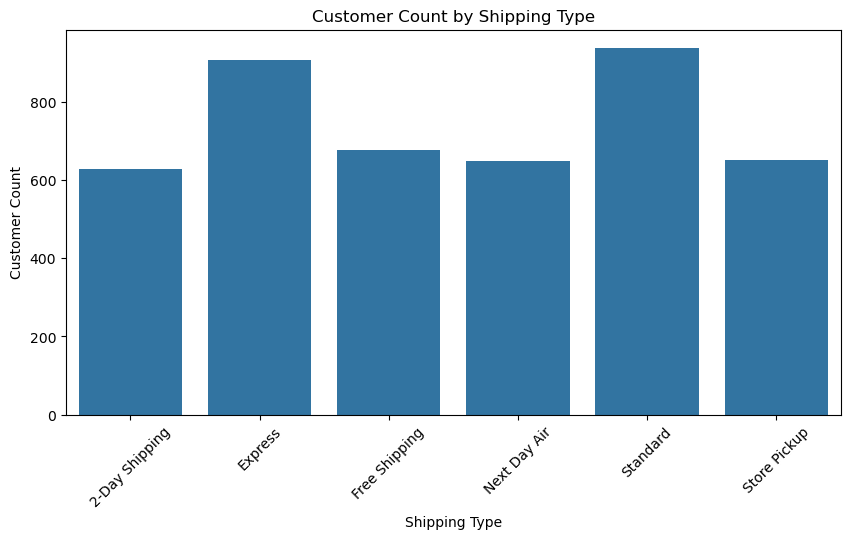

In [25]:
# Visualise Customer Count by Shipping Type
plt.figure(figsize=(10,5))
sns.barplot(x=customer_count.index, y=customer_count.values)
plt.title("Customer Count by Shipping Type")
plt.xlabel("Shipping Type")
plt.ylabel("Customer Count")
plt.xticks(rotation=45)
plt.show()

In [26]:
# Average Spend
avg_spend = df_cleaned.groupby("Shipping Type")["Purchase Amount (USD)"].mean()
avg_spend

Shipping Type
2-Day Shipping     60.733652
Express           273.188765
Free Shipping      60.410370
Next Day Air       58.631173
Standard          260.253746
Store Pickup       59.893846
Name: Purchase Amount (USD), dtype: float64

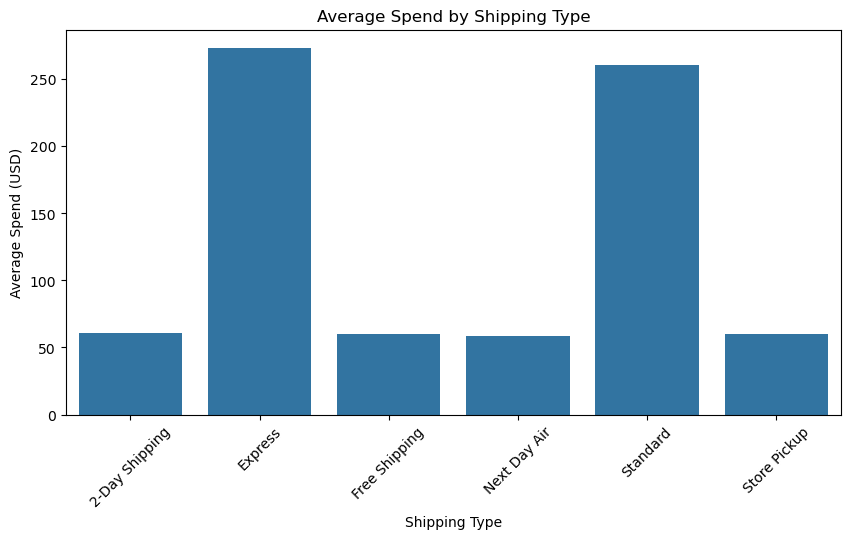

In [27]:
# Visualise the average spend by Shipping Type
plt.figure(figsize=(10,5))
sns.barplot(x=avg_spend.index, y=avg_spend.values)
plt.title("Average Spend by Shipping Type")
plt.xlabel("Shipping Type")
plt.ylabel("Average Spend (USD)")
plt.xticks(rotation=45)
plt.show()

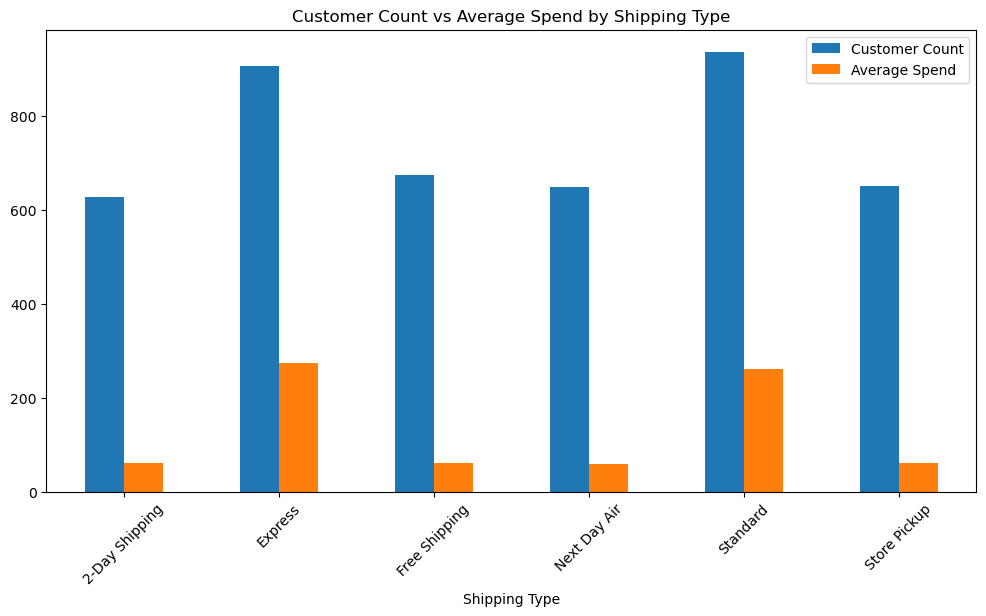

In [28]:
# Visualise and Compared both measures together with a grouped barchart
compare_df = pd.DataFrame({
    "Customer Count": customer_count,
    "Average Spend": avg_spend
})

compare_df.plot(kind="bar", figsize=(12,6))
plt.title("Customer Count vs Average Spend by Shipping Type")
plt.xticks(rotation=45)
plt.show()

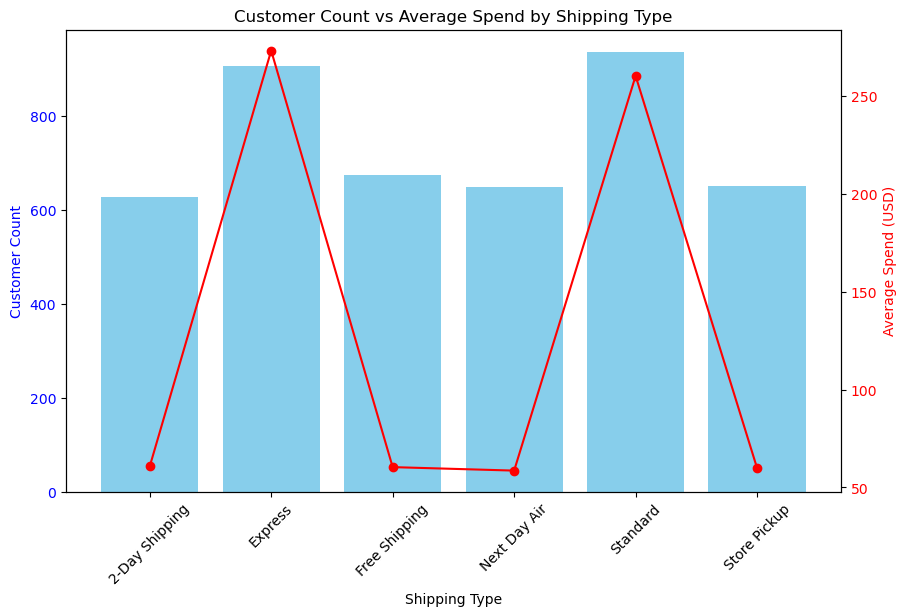

In [29]:
# Comparing Customer Count (volume) and Average Spend (value), we need to use a dual‑axis chart instead of a single axis because the scales are very different

fig, ax1 = plt.subplots(figsize=(10,6))

# Bar chart for customer count
ax1.bar(customer_count.index, customer_count.values, color='skyblue')
ax1.set_xlabel("Shipping Type")
ax1.set_ylabel("Customer Count", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
plt.xticks(rotation=45)

# Second axis for average spend
ax2 = ax1.twinx()
ax2.plot(avg_spend.index, avg_spend.values, color='red', marker='o')
ax2.set_ylabel("Average Spend (USD)", color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Customer Count vs Average Spend by Shipping Type")
plt.show()

In [30]:
# Estimating the business impact (Estimated Revenue)
estimated_revenue = customer_count * avg_spend
estimated_revenue

Shipping Type
2-Day Shipping     38080.00
Express           247782.21
Free Shipping      40777.00
Next Day Air       37993.00
Standard          243857.76
Store Pickup       38931.00
dtype: float64

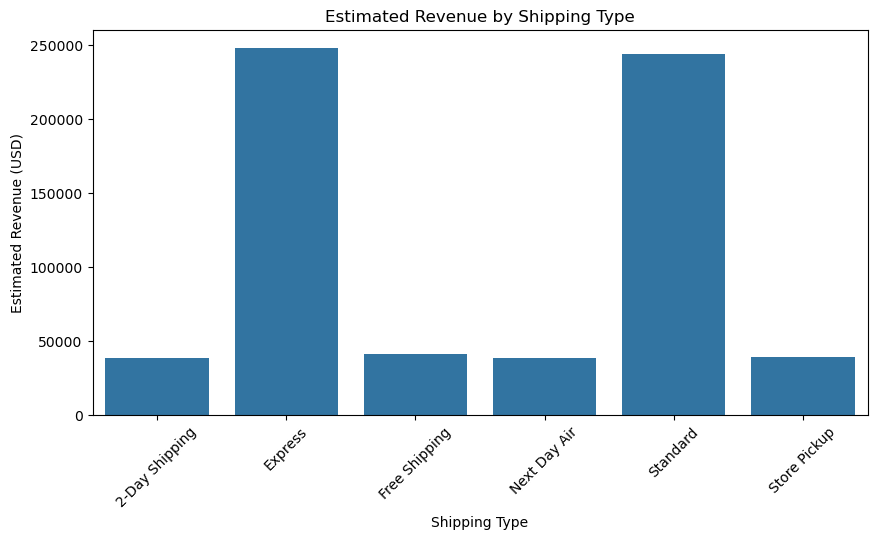

In [31]:
# A barchart to visualise the estimated revenue for each shipping type
plt.figure(figsize=(10,5))
sns.barplot(x=estimated_revenue.index, y=estimated_revenue.values)
plt.title("Estimated Revenue by Shipping Type")
plt.xlabel("Shipping Type")
plt.ylabel("Estimated Revenue (USD)")
plt.xticks(rotation=45)
plt.show()

In [32]:
# Extimated revenue rank from highest to lowest
estimated_revenue.sort_values(ascending=False)

Shipping Type
Express           247782.21
Standard          243857.76
Free Shipping      40777.00
Store Pickup       38931.00
2-Day Shipping     38080.00
Next Day Air       37993.00
dtype: float64

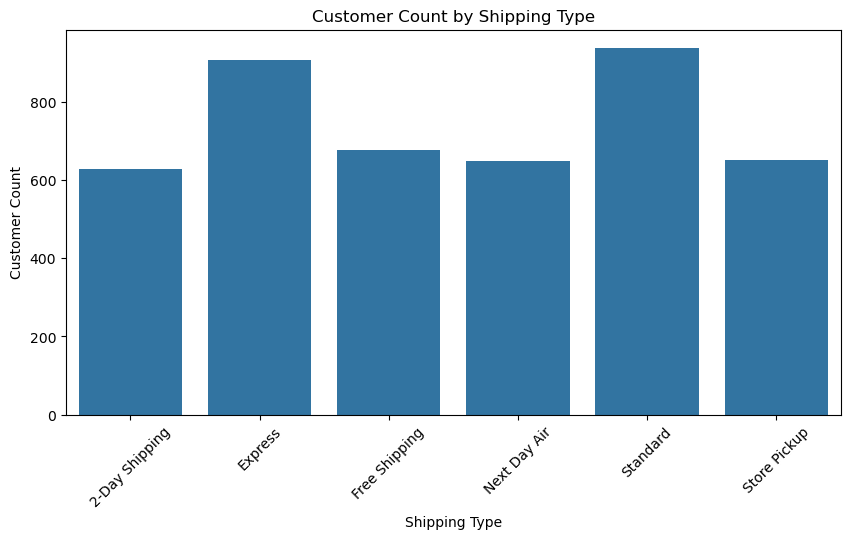

In [33]:
# Estimated revenue by shipping type from highest to lowest)
plt.figure(figsize=(10,5))
sns.barplot(x=customer_count.index, y=customer_count.values)
plt.title("Customer Count by Shipping Type")
plt.xlabel("Shipping Type")
plt.ylabel("Customer Count")
plt.xticks(rotation=45)
plt.show()

In [34]:
customer_count

Shipping Type
2-Day Shipping    627
Express           907
Free Shipping     675
Next Day Air      648
Standard          937
Store Pickup      650
dtype: int64

In [35]:
avg_spend

Shipping Type
2-Day Shipping     60.733652
Express           273.188765
Free Shipping      60.410370
Next Day Air       58.631173
Standard          260.253746
Store Pickup       59.893846
Name: Purchase Amount (USD), dtype: float64

In [36]:
estimated_revenue

Shipping Type
2-Day Shipping     38080.00
Express           247782.21
Free Shipping      40777.00
Next Day Air       37993.00
Standard          243857.76
Store Pickup       38931.00
dtype: float64

## Customer Behaviour
Customer behaviour varies significantly across shipping methods. Express and Standard Shipping attract the highest customer volumes and also generate the highest average spend, indicating that these options appeal to higher‑value customers. In contrast, Free Shipping, Store Pickup, 2‑Day Shipping, and Next Day Air attract a similar number of customers but are associated with much lower average spend, suggesting these methods appeal to more price‑sensitive shoppers.

The data does not show a consistent pattern that faster delivery automatically leads to higher spending. While Express customers spend considerably more, other fast options such as 2‑Day Shipping and Next Day Air are linked to lower-value purchases. This indicates that the relationship between delivery speed and spending is not straightforward and should be interpreted cautiously. 